## Example 1: Interference

### Purpose

This example notebook looks at the phenomenon of quantum interference, which plays a key role in many quantum algorithms.

### Imports and Definitions

The following Python imports will be needed:

In [1]:
from tinyqsim.qcircuit import QCircuit
import matplotlib.pyplot as plt
import numpy as np
from math import pi

These Unicode definitions will be useful for annotating the quantum circuits:

In [2]:
U_PI = '\u03C0'  # Unicode pi
U_PHI = '\u03d5'  # Unicode phi
KET0 = '|0\u27E9' # Unicode ket |0>

### Introduction

Two quantum states can be made to *interfere* with each other. If they are in phase, their amplitudes will reinforce one another. If they are in anti-phase, they will cancel one another. Even a single qubit can interfere with itself, because it has two basis states $\ket{0}$ and $\ket{1}$. (If you are familiar with the well-known "Double-slit" experiment, this is like the way that a photon or electron can be in a superposition of going through both slits and interfering with itself.)

The following circuit demonstrates single-qubit interference, but the principle extends to multi-qubit systems. An N-qubit system has $2^N$ basis states.

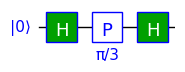

In [3]:
phi = pi/3

qc = QCircuit(1)
qc.qubit_labels({0: KET0}, numbers=False)
qc.h(0)
qc.p(phi, f'{U_PI}/3', 0)
qc.h(0)
qc.draw()

The circuit uses a phase (P) gate and two Hadamard (H) gates. Although very simple, this pattern is an important building block for quantum circuits.

The first Hadamard gate places the qubit in an equal superposition of $\ket{0}$ and $\ket{1}$. The phase gate then introduces a phase difference of $\frac{\pi}{3}$ radians (i.e. 60 degrees) between these two components. The final Hadamard gate undoes the effect of the first Hadamard, recombining the components, causing them to interfere with one another, increasing or decreasing their relative amplitudes.

The effect of the interference is now evident in the measurement probabilities:

In [4]:
print(qc.format_probabilities())

|0⟩  0.75
|1⟩  0.25


Sandwiching the phase gate between two Hadamard gates has converted a non-measurable phase difference into an observable probability difference.

### Effect of Phase Angle

We can run the circuit with different values of $\phi$ and plot the probabilities of measuring '0' and '1' as a function of the phase angle $\phi$.

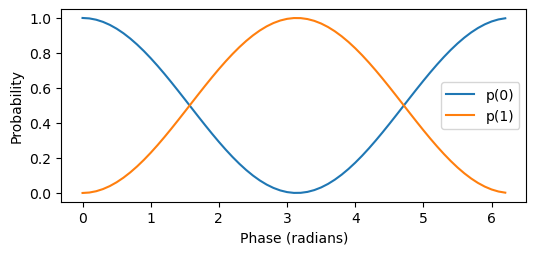

In [5]:
def calc_probs(phi):
    qc = QCircuit(1)
    qc.h(0)
    qc.p(phi, U_PHI, 0)
    qc.h(0)
    return qc.probability_array()

phis = np.arange(0, 2*pi, 0.1)
prob0, prob1 = np.array([calc_probs(p) for p in phis]).T
plt.figure(figsize=(6,2.5))
plt.plot(phis, prob0, label='p(0)')
plt.plot(phis, prob1, label='p(1)')
plt.xlabel('Phase (radians)')
plt.ylabel('Probability')
plt.legend()
pass

### Analysis

We will label points in the circuit A, B, C, D, so that we can refer to the state at these points as $\ket{\psi_A},\ket{\psi_B}$, etc:

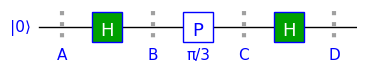

In [6]:
phi = pi/3
qc = QCircuit(1)
qc.qubit_labels({0: KET0}, numbers=False)
qc.barrier('A')
qc.h(0)
qc.barrier('B')
qc.p(phi, f'{U_PI}/3', 0)
qc.barrier('C')
qc.h(0)
qc.barrier('D')
qc.draw()

The initial state $\ket{\psi_A}$ is:

$$\qquad\ket{\psi_A}=\ket{0}$$

The first Hadamard gate transforms this into the superposition state:

$$\qquad\ket{\psi_B}=\frac{1}{\sqrt{2}}(\ket{0} + \ket{1})$$

The phase gate is defined as:

$$\qquad P(\phi)=\ket{0}\bra{0}+e^{i\phi}\ket{1}\bra{1}$$

When applied to the superposition state, it gives:

$$\qquad\ket{\psi_C}=\frac{1}{\sqrt{2}}(\ket{0} + e^{i\phi}\ket{1})$$

Finally, the second Hadamard gate results in the state:

$$\qquad\ket{\psi_D}={\small\frac{1}{2}}\left[(\ket{0}+\ket{1}) + e^{i\phi}(\ket{0}-\ket{1})\right]$$

which can be rewritten as:

$$\qquad\ket{\psi_D}=\frac{1}{2}\left[(1 + \cos{\phi}+ i\sin{\phi})\ket{0} + (1 - \cos{\phi} - i\sin{\phi})\ket{1} \right]$$

For $\phi=\frac{\pi}{3}$, we can substitute $\cos{\phi}=\frac{\sqrt{3}}{2}$ and $\sin{\phi}=\frac{1}{2}$

which gives:

$$\qquad\ket{\psi}=\frac{1}{4}\left[(3 + i\sqrt{3})\ket{0}+(1-i\sqrt{3})\ket{1}\right]$$

If we print the final state of our circuit, we find that it agrees:

In [7]:
qc.display_state(prefix=r'\ket{\psi} = ')

<IPython.core.display.Math object>

The probabilities of measuring $\ket{0}$ and $\ket{1}$ are:

$$\qquad p(\ket{0})=\frac{1}{4}(3 + \sqrt{3}i)\ \frac{1}{4}[(3 - \sqrt{3}i) = \frac{3}{4}$$

$$\qquad p(\ket{1})=\frac{1}{4}(1 - \sqrt{3}i)\ \frac{1}{4}[(1 + \sqrt{3}i) = \frac{1}{4}$$

### Bloch-Sphere Description

Another way to understand the behaviour of the circuit is to plot the state vector on the Bloch sphere and follow it step-by-step as we perform each gate operation in turn. The Bloch sphere is only suitable for representing single-qubit systems, but the graphical visualization may help in building some intuition.

<div style="text-align: center;">
<img src="assets/bloch.png" alt="bloch" width="270"/>
</div>

The state vector is described by two angles on the Bloch sphere. The phase angle $\phi$ is measured clockwise about the +Z axis. The polar angle $\theta$ is measured relative to the +Z axis. So, $\theta=\frac{\pi}{2}$ corresponds to points on the "equator" of the sphere, where the measurement probabilities of 0 and 1 are equal.

The circuit starts in an initial state of $\ket{0}$ which is in the +Z direction, as shown below by the red vector:

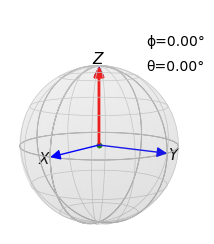

In [8]:
qc = QCircuit(1)
qc.plot_bloch(scale=0.75)

In this state, there is a 100% probability of getting state $\ket{0}$ if we make a measurement.

The first gate is a Hadamard (H) gate. Hadamard gates perform a 180 degree rotation about an axis mid-way between the X and Z axes (sometimes called the 'X+Z' axis). This operation can be viewed as a basis change that swaps the role of the X and Z axes. It has the effect of transforming the Z-basis state $\ket{0}$ into the superposition state $\ket{+}=\frac{1}{\sqrt{2}}(\ket{0}+\ket{1})$, which is a basis state of the X basis.

Consequently, after the first Hadamard gate, the state vector is in the +X direction:

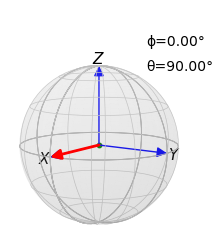

In [9]:
qc.h(0)
qc.plot_bloch(scale=0.75)

There are now equal probabilities of measuring 0 or 1.

In [10]:
print(qc.format_probabilities())

|0⟩  0.5
|1⟩  0.5


Next, the phase (P) gate in our example circuit rotates the state vector 60 degrees clockwise about the +Z axis:

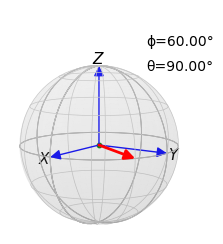

In [11]:
qc.p(phi, U_PHI, 0)
qc.plot_bloch(scale=0.75)

The measurement probabilities of $\ket{0}$ and $\ket{1}$ are still both 50%:

The final Hadamard gate undoes the original Hadamard transformation, leaving the state vector at an angle of 60 degrees to the original $\ket{0}$ state.

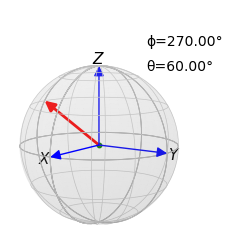

In [12]:
qc.h(0)
qc.plot_bloch(scale=0.75)

The two basis states now have different measurement probabilities. There is now a 75% probability of measuring a '0' and 25% probability of measuring a '1'.

In [13]:
print(qc.format_probabilities())

|0⟩  0.75
|1⟩  0.25


One way to think about the circuit is that the Hadamard-sandwich $HPH$ transforms the phase (P) gate so that it rotates about X instead of Z. A phase change then becomes a measurable amplitude change. Another way to think about it is that the first Hadamard places the state in a superposition. The phase gate then introduces a phase difference between the $\ket{0}$ and $\ket{1}$ states. The second Hadamard then causes the two states to interfere with one another, leading to an observable amplitude difference.

Many quantum algorithms work by placing a set of $N$ qubits in a joint superposition of the $2^N$ states. The phases are then selectively modified so that the states interfere, amplifying valid solutions using constructive interference. A final Hadamard or Fourier transform then puts the state back in a form where we can see the phase difference as amplitude differences when we measure the output state. This will become clearer when we look at Quantum Phase Estimation and Shor's Algorithm in subsequent example notebooks.